Starting improved Double DQN training for 3000 episodes...


  0%|          | 0/3000 [00:00<?, ?it/s]

C:\Users\iamro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
100%|██████████| 3000/3000 [15:30<00:00,  3.23it/s]


Training completed!


C:\Users\iamro\AppData\Local\Temp\ipykernel_6544\4271596772.py:677: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(4, 3, 10)
C:\Users\iamro\AppData\Local\Temp\ipykernel_6544\4271596772.py:696: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


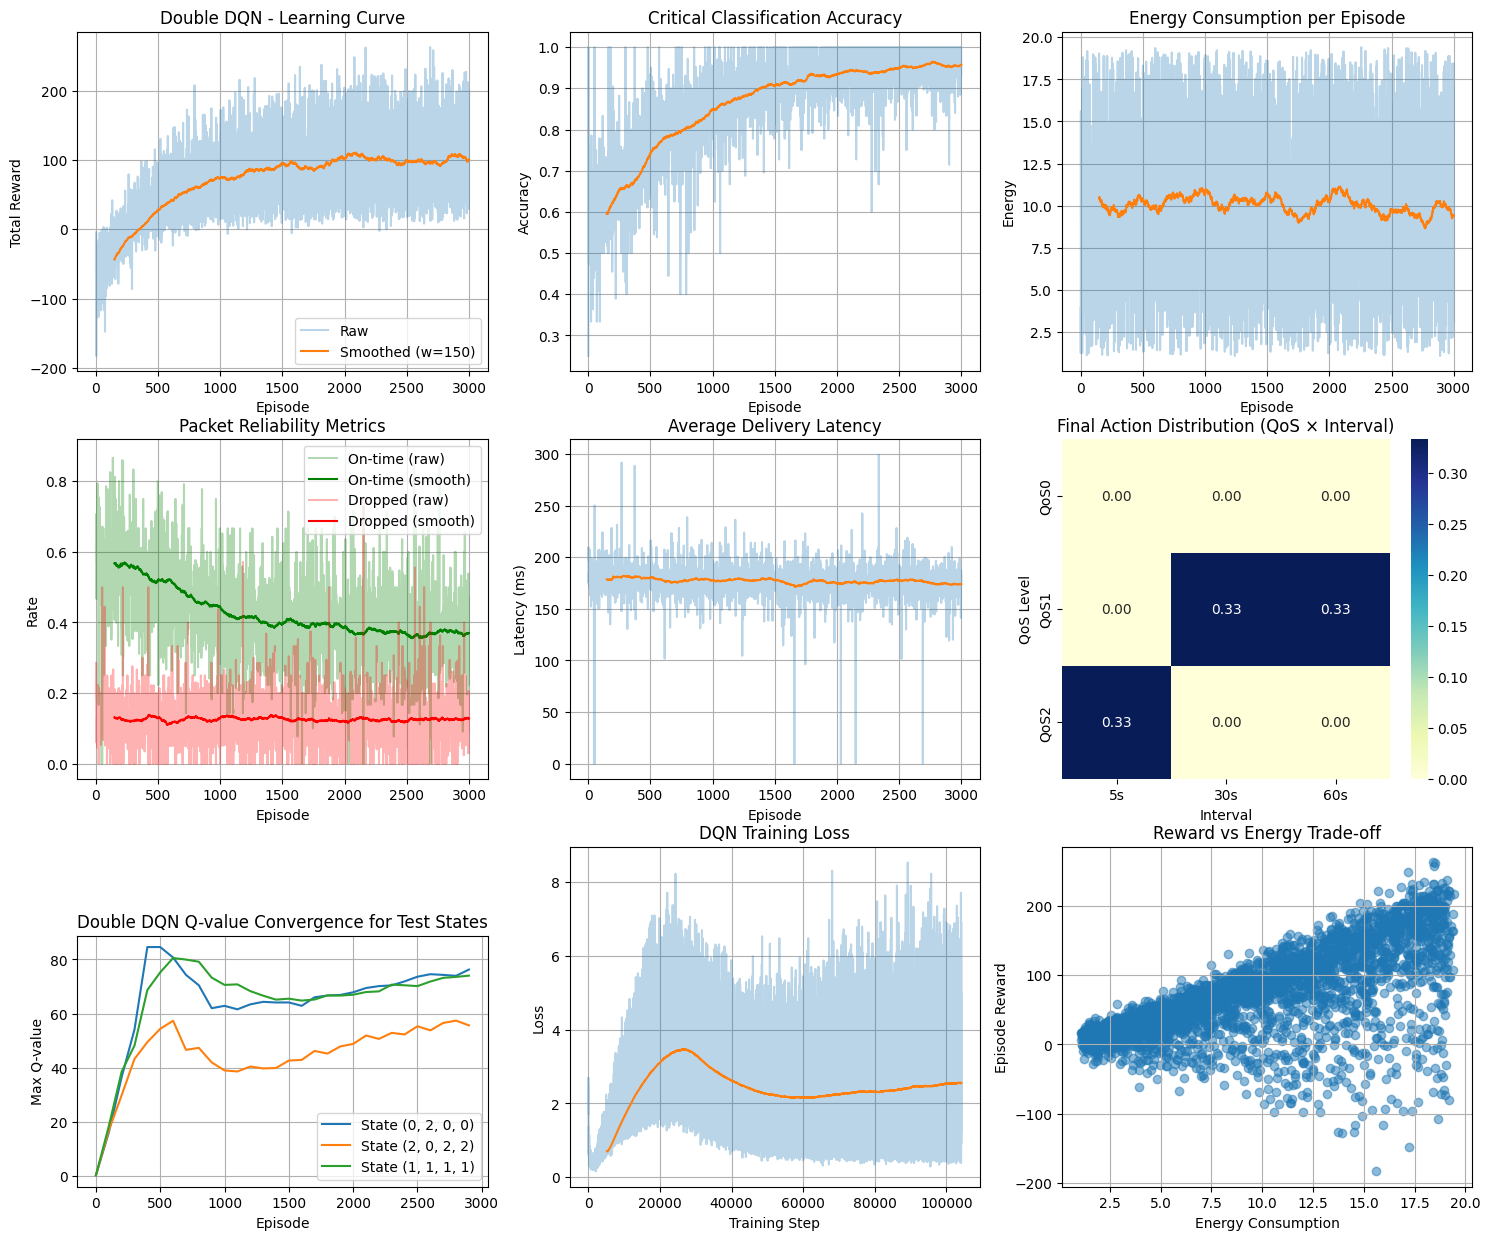


Double DQN Policy Analysis with Expected Ideal Actions:

State (Δ0, B=2, L=0, D=0):
  Best action: QoS=1, Interval=60s, Critical=0
  Ideal QoS: 0, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✗, τ=60s✗, c=0 (Q=76.20)
  Top 2: QoS=1✗, τ=60s✗, c=1 (Q=75.09)
  Top 3: QoS=2✗, τ=60s✗, c=0 (Q=74.97)

State (Δ2, B=0, L=2, D=2):
  Best action: QoS=2, Interval=5s, Critical=1
  Ideal QoS: 2, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=2✓, τ=5s✓, c=1 (Q=56.84)
  Top 2: QoS=2✓, τ=30s✗, c=1 (Q=56.25)
  Top 3: QoS=2✓, τ=60s✗, c=1 (Q=56.18)

State (Δ1, B=1, L=1, D=1):
  Best action: QoS=1, Interval=30s, Critical=1
  Ideal QoS: 1, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✓, τ=30s✗, c=1 (Q=75.73)
  Top 2: QoS=1✓, τ=60s✗, c=1 (Q=72.69)
  Top 3: QoS=0✗, τ=30s✗, c=0 (Q=72.40)

State-Action Pair Coverage Summary:
  State-action pairs encountered: 790 / 1458 (54.18%)
  Well-visited pairs (≥10 visits): 335 / 1458
  Unique states visited: 81 / 81 (100.00%)
  Most visited state-act

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque, namedtuple, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


class RealisticEnvSimulator:
    def __init__(self):
        self.battery = 1.0
        self.window_size = 20
        self.delay_window = []
        self.loss_window = []
        self.delta_ema = None
        self.delta_alpha = 0.1
        self.delta_std = 1.0

    def update_ema(self, x):
        if self.delta_ema is None:
            self.delta_ema = x
        else:
            self.delta_ema = self.delta_alpha * x + \
                (1 - self.delta_alpha) * self.delta_ema
        return self.delta_ema

    def compute_delta(self, x):
        ema = self.update_ema(x)
        delta = abs(x - ema) / (self.delta_std + 1e-8)
        return delta

    def compute_loss_rate(self):
        if len(self.loss_window) < self.window_size:
            return 0.0
        return 1.0 - np.mean(self.loss_window[-self.window_size:])

    def compute_avg_delay(self):
        if len(self.delay_window) == 0:
            return 0
        return np.mean(self.delay_window[-self.window_size:])

    def discretize_state(self, delta, battery, loss, delay):

        if delta < 1:
            delta_lvl = 0   
        elif delta < 3:
            delta_lvl = 1  
        else:
            delta_lvl = 2  

        
        if battery < 0.3:
            battery_lvl = 0   
        elif battery < 0.7:
            battery_lvl = 1  
        else:
            battery_lvl = 2  

        if loss < 0.1:
            loss_lvl = 0    
        elif loss < 0.3:
            loss_lvl = 1  
        else:
            loss_lvl = 2  

        if delay < 100:
            delay_lvl = 0    
        elif delay < 500:
            delay_lvl = 1  
        else:
            delay_lvl = 2  

        return delta_lvl, battery_lvl, loss_lvl, delay_lvl

    def simulate_environment(self, state, action):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        # Generate raw input values to mimic the system
        sensor_value = np.random.uniform(10, 30)  
        delta = self.compute_delta(sensor_value)

        # Energy usage
        qos_energy = 0.05 * qos
        interval_energy = 2.0 / interval
        energy_cost = qos_energy + interval_energy
        self.battery = max(0.0, self.battery - energy_cost * 0.05)

        # Delay simulation 
        base_delay = np.random.normal(100 + 50 * (2 - qos), 20)
        delay = np.clip(base_delay + 1000 / interval, 0, 800)
        self.delay_window.append(delay)

        #  Packet loss simulation 
        loss_chance = 0.1 * (2 - qos) + 0.01 * delay / \
            100  
        is_delivered = np.random.rand() > loss_chance
        self.loss_window.append(int(is_delivered))

        # Status & latency 
        packet_status = 'dropped'
        if is_delivered:
            packet_status = 'on_time' if delay < 300 else 'late'
        latency = delay if is_delivered else 1000

        # Discretization for next state 
        next_delta_lvl = 0 if delta < 1 else (1 if delta < 3 else 2)
        next_battery_lvl = 0 if self.battery < 0.3 else (
            1 if self.battery < 0.7 else 2)
        loss_rate = self.compute_loss_rate()
        next_loss_lvl = 0 if loss_rate < 0.1 else (1 if loss_rate < 0.3 else 2)
        avg_delay = self.compute_avg_delay()
        next_delay_lvl = 0 if avg_delay < 100 else (
            1 if avg_delay < 500 else 2)

        new_state = (next_delta_lvl, next_battery_lvl,
                     next_loss_lvl, next_delay_lvl)

        # True criticality logic 
        delta_risk = delta_lvl
        battery_risk = 2 - battery_lvl
        loss_risk = loss_lvl
        delay_risk = delay_lvl
        qos_risk = qos

        total_risk = delta_risk + battery_risk + loss_risk + delay_risk + qos_risk
        normalized_risk = total_risk / 5
        true_crit = 1 if normalized_risk >= 1 else 0

        return new_state, packet_status, true_crit, energy_cost, latency



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        return batch

    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class DoubleDQNAgent:
    def __init__(self):
        self.env = RealisticEnvSimulator()
        self.state_action_visits = defaultdict(int)  
        self.state_visits = defaultdict(int)
        
        self.qos_levels = [0, 1, 2]
        self.intervals = [5, 30, 60]  
        self.critical_flags = [0, 1]

 
        self.state_dims = [3, 3, 3, 3] 
        self.num_states = np.prod(self.state_dims)
        self.action_dims = [3, 3, 2]  
        self.num_actions = np.prod(self.action_dims)

        self.state_dim = len(self.state_dims)  
        self.policy_net = DQN(self.state_dim, self.num_actions).to(device)
        self.target_net = DQN(self.state_dim, self.num_actions).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Training parameters
        self.batch_size = 64  
        self.gamma = 0.99  
        self.eps_start = 0.9  
        self.eps_end = 0.05
        self.eps_decay = 0.998  
        self.target_update = 100  
        self.reward_scaling = 1.0  
        self.memory = ReplayBuffer(50000)

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.0005)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=1000, gamma=0.95)
        self.loss_fn = nn.SmoothL1Loss()

        # Reward parameters (same as tabular)
        self.reward_weights = {
            'timeliness': 1.5,
            'criticality': 2.0,
            'qos_match': 2.0,
            'interval_match': 2.0,
            'tau_cost': 1.0,
            'qos_cost': 1.0,
            'kappa': 2.0,
            'latency_penalty': 0.5
        }


        self.metrics = {
            'episode_rewards': [],
            'classification_accuracy': [],
            'energy_consumption': [],
            'on_time_rate': [],
            'drop_rate': [],
            'avg_latency': [],
            'action_distribution': defaultdict(list),
            'convergence_data': [],
            'loss_values': [],
            'epsilon_values': [],
            'qos_distribution': [],
            'lr_values': []
        }

        self.steps_done = 0
        self.update_count = 0

    def action_to_index(self, qos, interval, critical):
        interval_idx = self.intervals.index(interval)
        return qos * 6 + interval_idx * 2 + critical

    def index_to_action(self, action_idx):
        qos = action_idx // 6
        remainder = action_idx % 6
        interval_idx = remainder // 2
        critical = remainder % 2
        return qos, self.intervals[interval_idx], critical

    def get_state_tensor(self, state):
        return torch.FloatTensor(state).unsqueeze(0).to(device)

    def state_to_index(self, delta_lvl, battery_lvl, loss_lvl, delay_lvl):
        return (delta_lvl * 27 + battery_lvl * 9 + loss_lvl * 3 + delay_lvl)
    
    def select_action(self, state, training=True):

        if training:
            eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
                np.exp(-1. * self.steps_done / 30000) 
            self.metrics['epsilon_values'].append(eps_threshold)

            if random.random() < eps_threshold:
                return random.randrange(self.num_actions)

        with torch.no_grad():
            state_tensor = self.get_state_tensor(state)
            q_values = self.policy_net(state_tensor)
            return q_values.max(1)[1].item()

    def calculate_reward(self, state, action, packet_status, true_crit, latency):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        
        if packet_status == 'on_time':
            R_rel = 1.0
        elif packet_status == 'late':
            R_rel = 0.5
        else: 
            R_rel = -1.0

        # 2. Criticality Reward (R_crit)
        R_crit = 1.0 if critical == true_crit else -1.0

        # 3. QoS-Match Reward (R_qos)
        ideal_qos = 2 if (loss_lvl >= 2 or delay_lvl >= 2) else \
            1 if (loss_lvl >= 1 or delay_lvl >= 1) else 0
        R_qos = 1.0 if qos == ideal_qos else -1.0

        # 4. Interval-Match Reward (R_int)
        ideal_interval = 5 if delta_lvl == 2 else \
            30 if delta_lvl == 1 else 60
        R_int = 1.0 if interval == ideal_interval else -1.0

        # Energy Penalty Calculation
        # Continuous battery representation [0.3, 1.1]
        battery = 0.3 + battery_lvl * 0.4

        # Battery factor (linear)
        f_Bt = 1 + self.reward_weights['kappa'] * (1 - battery)

        # Normalized action costs
        C_qos = qos / 2  # QoS 0→0.0, 1→0.5, 2→1.0
        C_int = (60 - interval) / (60 - 5)  # 5s→1.0, 30s→0.5, 60s→0.0

        # Combined penalty
        penalty = f_Bt * (self.reward_weights['tau_cost'] * C_int +
                          self.reward_weights['qos_cost'] * C_qos)

        # Total reward with weighted components
        total_reward = (self.reward_weights['timeliness'] * R_rel +
                        self.reward_weights['criticality'] * R_crit +
                        self.reward_weights['qos_match'] * R_qos +
                        self.reward_weights['interval_match'] * R_int -
                        penalty)

        # Additional penalty for latency (independent of packet status)
        latency_penalty = self.reward_weights['latency_penalty'] * min(
            1, latency/800)
        total_reward -= latency_penalty

        return np.clip(total_reward, -5.0, 5.0)

    def _get_ideal_qos(self, state):

        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state


        if loss_lvl >= 2 or delay_lvl >= 2 or delta_lvl >= 2:
            return 2
        elif (loss_lvl >= 1 or delay_lvl >= 1) and battery_lvl >= 1:
            return 1
        else:
            return 0

    def _get_ideal_interval(self, state):

        delta_lvl, battery_lvl, _, _ = state

        if delta_lvl == 2 or battery_lvl >= 1:
            return 5
        elif delta_lvl == 1:
            return 30
        else:
            return 60

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return

        batch = self.memory.sample(self.batch_size)

        state_batch = torch.FloatTensor(batch.state).to(device)
        action_batch = torch.LongTensor(batch.action).unsqueeze(1).to(device)
        reward_batch = torch.FloatTensor(
            batch.reward).to(device) * self.reward_scaling
        next_state_batch = torch.FloatTensor(batch.next_state).to(device)
        done_batch = torch.BoolTensor(batch.done).to(device)


        current_q = self.policy_net(state_batch).gather(1, action_batch)


        with torch.no_grad():
            next_actions = self.policy_net(next_state_batch).max(1)[
                1].unsqueeze(1)
            next_q = self.target_net(next_state_batch).gather(1, next_actions)
            target_q = reward_batch.unsqueeze(
                1) + (self.gamma * next_q * (~done_batch.unsqueeze(1)))

        # Compute loss
        loss = self.loss_fn(current_q, target_q)
        self.metrics['loss_values'].append(loss.item())

        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        self.update_count += 1

    def update_target(self):
        
        tau = 0.005  
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(
                tau * policy_param.data + (1 - tau) * target_param.data)

    def train(self, num_episodes=3000, eval_interval=100):
        print(
            f"Starting improved Double DQN training for {num_episodes} episodes...")

        for episode in tqdm(range(num_episodes)):
        
            episode_metrics = {
                'reward': 0,
                'correct_class': 0,
                'energy': 0,
                'packets_sent': 0,
                'on_time': 0,
                'dropped': 0,
                'latency': 0,
                'steps': 0,
                'qos_counts': [0, 0, 0]
            }

        
            self.env = RealisticEnvSimulator()
            delta = np.random.uniform(0, 4)
            battery = np.random.uniform(0.1, 1.0)
            loss = np.random.uniform(0, 0.5)
            delay = np.random.uniform(0, 600)
            self.env.battery = battery
            state = self.env.discretize_state(delta, battery, loss, delay)

            done = False
            while not done and episode_metrics['steps'] < 100:
        
                action_idx = self.select_action(state)
                action = self.index_to_action(action_idx)
                state_idx = self.state_to_index(*state)
                self.state_action_visits[(state_idx, action_idx)] += 1
                self.state_visits[state_idx] += 1
        
                new_state, packet_status, true_crit, energy_cost, latency = \
                    self.env.simulate_environment(state, action)

                
                reward = self.calculate_reward(
                    state, action, packet_status, true_crit, latency)

                
                done = self.env.battery <= 0.05 or episode_metrics['steps'] >= 99

                
                self.memory.push(state, action_idx, reward, new_state, done)

                
                if len(self.memory) >= self.batch_size:
                    self.optimize_model()

                
                if self.update_count % 4 == 0: 
                    self.update_target()

                
                episode_metrics['reward'] += reward
                episode_metrics['correct_class'] += 1 if action[2] == true_crit else 0
                episode_metrics['energy'] += energy_cost
                episode_metrics['packets_sent'] += 1
                episode_metrics['qos_counts'][action[0]] += 1

                if packet_status == 'on_time':
                    episode_metrics['on_time'] += 1
                    episode_metrics['latency'] += latency
                elif packet_status == 'dropped':
                    episode_metrics['dropped'] += 1

                episode_metrics['steps'] += 1
                state = new_state
                self.steps_done += 1

            
            self.scheduler.step()

            
            self.metrics['episode_rewards'].append(episode_metrics['reward'])
            self.metrics['classification_accuracy'].append(
                episode_metrics['correct_class'] / episode_metrics['steps'] if episode_metrics['steps'] > 0 else 0)
            self.metrics['energy_consumption'].append(
                episode_metrics['energy'])
            self.metrics['on_time_rate'].append(
                episode_metrics['on_time'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['drop_rate'].append(
                episode_metrics['dropped'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['avg_latency'].append(
                episode_metrics['latency'] / episode_metrics['on_time'] if episode_metrics['on_time'] > 0 else 0)

            
            qos_dist = np.array(
                episode_metrics['qos_counts']) / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else np.array([0, 0, 0])
            self.metrics['qos_distribution'].append(qos_dist)

            
            self.metrics['lr_values'].append(
                self.optimizer.param_groups[0]['lr'])

            
            if episode % eval_interval == 0:
                self._evaluate_policy(episode)

        print("Training completed!")
        return self.metrics

    def _evaluate_policy(self, episode):
        
        test_states = [
            (0, 2, 0, 0),  
            (2, 0, 2, 2),  
            (1, 1, 1, 1)   
        ]

        action_counts = np.zeros((3, 3)) 
        crit_counts = np.zeros(2)  

        state_q_values = {}
        for state in test_states:
            state_tensor = self.get_state_tensor(state)
            with torch.no_grad():
                q_values = self.policy_net(state_tensor).cpu().numpy().flatten()
                max_q_value = np.max(q_values)
            state_q_values[state] = max_q_value  

            action_idx = self.select_action(state, training=False)
            qos, interval, critical = self.index_to_action(action_idx)
            interval_idx = self.intervals.index(interval)
            action_counts[qos, interval_idx] += 1
            crit_counts[critical] += 1

        
        self.metrics['convergence_data'].append({
            'episode': episode,
            'action_dist': action_counts / len(test_states),
            'crit_dist': crit_counts / len(test_states),
            'state_q_values': state_q_values   
        })


    def plot_metrics(self):

        plt.figure(figsize=(18, 15))


        window = max(1, len(self.metrics['episode_rewards']) // 20)

        # 1. Learning Curve - Average Reward
        plt.subplot(3, 3, 1)
        rewards = self.metrics['episode_rewards']
        if len(rewards) > 0:
            smooth_rewards = np.convolve(
                rewards, np.ones(window)/window, mode='valid')
            plt.plot(rewards, alpha=0.3, label='Raw')
            plt.plot(range(window-1, len(rewards)), smooth_rewards,
                     label=f'Smoothed (w={window})')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.title('Double DQN - Learning Curve')
        plt.legend()
        plt.grid(True)

        # 2. Classification Accuracy
        plt.subplot(3, 3, 2)
        accuracy = self.metrics['classification_accuracy']
        if len(accuracy) > 0:
            smooth_acc = np.convolve(
                accuracy, np.ones(window)/window, mode='valid')
            plt.plot(accuracy, alpha=0.3)
            plt.plot(range(window-1, len(accuracy)), smooth_acc)
        plt.xlabel('Episode')
        plt.ylabel('Accuracy')
        plt.title('Critical Classification Accuracy')
        plt.grid(True)

        # 3. Energy Consumption
        plt.subplot(3, 3, 3)
        energy = self.metrics['energy_consumption']
        if len(energy) > 0:
            smooth_energy = np.convolve(
                energy, np.ones(window)/window, mode='valid')
            plt.plot(energy, alpha=0.3)
            plt.plot(range(window-1, len(energy)), smooth_energy)
        plt.xlabel('Episode')
        plt.ylabel('Energy')
        plt.title('Energy Consumption per Episode')
        plt.grid(True)

        # 4. Reliability Metrics
        plt.subplot(3, 3, 4)
        on_time = self.metrics['on_time_rate']
        dropped = self.metrics['drop_rate']
        if len(on_time) > 0 and len(dropped) > 0:
            smooth_ot = np.convolve(
                on_time, np.ones(window)/window, mode='valid')
            smooth_dr = np.convolve(
                dropped, np.ones(window)/window, mode='valid')
            plt.plot(on_time, alpha=0.3, color='green', label='On-time (raw)')
            plt.plot(range(window-1, len(on_time)), smooth_ot,
                     color='green', label='On-time (smooth)')
            plt.plot(dropped, alpha=0.3, color='red', label='Dropped (raw)')
            plt.plot(range(window-1, len(dropped)), smooth_dr,
                     color='red', label='Dropped (smooth)')
        plt.xlabel('Episode')
        plt.ylabel('Rate')
        plt.title('Packet Reliability Metrics')
        plt.legend()
        plt.grid(True)

        # 5. Average Latency
        plt.subplot(3, 3, 5)
        latency = self.metrics['avg_latency']
        if len(latency) > 0:
            smooth_lat = np.convolve(
                latency, np.ones(window)/window, mode='valid')
            plt.plot(latency, alpha=0.3)
            plt.plot(range(window-1, len(latency)), smooth_lat)
        plt.xlabel('Episode')
        plt.ylabel('Latency (ms)')
        plt.title('Average Delivery Latency')
        plt.grid(True)

        # 6. Action Distribution Heatmap (final)
        plt.subplot(3, 3, 6)
        if self.metrics['convergence_data']:
            final_actions = self.metrics['convergence_data'][-1]['action_dist']
            sns.heatmap(final_actions, annot=True, fmt='.2f',
                        xticklabels=['5s', '30s', '60s'],
                        yticklabels=['QoS0', 'QoS1', 'QoS2'],
                        cmap='YlGnBu')
            plt.title('Final Action Distribution (QoS × Interval)')
            plt.xlabel('Interval')
            plt.ylabel('QoS Level')

        # 7. Critical Flag Rate Over Time
        plt.subplot(3, 3, 7)
        if self.metrics['convergence_data']:
            crit_data = [x['crit_dist'][1]
                         for x in self.metrics['convergence_data']]
            episodes = [x['episode'] for x in self.metrics['convergence_data']]
            plt.plot(episodes, crit_data)
        plt.xlabel('Episode')
        plt.ylabel('Critical Flag Rate')
        plt.title('Critical Transmission Rate Over Time')
        plt.grid(True)

        # 8. Training Loss
        plt.subplot(3, 3, 8)
        if len(self.metrics['loss_values']) > 0:
            window_loss = max(1, len(self.metrics['loss_values']) // 20)
            smooth_loss = np.convolve(self.metrics['loss_values'],
                                      np.ones(window_loss)/window_loss, mode='valid')
            plt.plot(self.metrics['loss_values'], alpha=0.3)
            plt.plot(
                range(window_loss-1, len(self.metrics['loss_values'])), smooth_loss)
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
        plt.title('DQN Training Loss')
        plt.grid(True)

        # 9. Reward vs Energy Consumption
        plt.subplot(3, 3, 9)
        if len(self.metrics['energy_consumption']) > 0 and len(self.metrics['episode_rewards']) > 0:
            plt.scatter(self.metrics['energy_consumption'],
                        self.metrics['episode_rewards'], alpha=0.5)
        plt.xlabel('Energy Consumption')
        plt.ylabel('Episode Reward')
        plt.title('Reward vs Energy Trade-off')
        plt.grid(True)

        # 10. Q-value convergence for test states
        plt.subplot(4, 3, 10)
        test_states = [
            (0, 2, 0, 0),  # Optimal conditions
            (2, 0, 2, 2),  # Worst conditions
            (1, 1, 1, 1)   # Mixed conditions
        ]

        for state in test_states:
            episodes = [data['episode'] for data in self.metrics['convergence_data']]
            q_values = [data['state_q_values'][state] for data in self.metrics['convergence_data']]
            plt.plot(episodes, q_values, label=f'State {state}')

        plt.xlabel('Episode')
        plt.ylabel('Max Q-value')
        plt.title('Double DQN Q-value Convergence for Test States')
        plt.legend()
        plt.grid(True)


        plt.tight_layout()
        plt.show()

    def analyze_policy(self):

        print("\nDouble DQN Policy Analysis with Expected Ideal Actions:")

        test_states = [
            (0, 2, 0, 0),  
            (2, 0, 2, 2),  
            (1, 1, 1, 1)   
        ]

        for state in test_states:
            action_idx = self.select_action(state, training=False)
            qos, interval, critical = self.index_to_action(action_idx)


            ideal_qos = self._get_ideal_qos(state)
            ideal_interval = self._get_ideal_interval(state)
            true_crit = 1 if (sum(state) + qos) / 5 >= 1 else 0

            print(
                f"\nState (Δ{state[0]}, B={state[1]}, L={state[2]}, D={state[3]}):")
            print(
                f"  Best action: QoS={qos}, Interval={interval}s, Critical={critical}")
            print(
                f"  Ideal QoS: {ideal_qos}, Ideal Interval: {ideal_interval}s")
            print(f"  Critical match: {'✓' if critical == true_crit else '✗'}")


            with torch.no_grad():
                state_tensor = self.get_state_tensor(state)
                q_values = self.policy_net(
                    state_tensor).squeeze().cpu().numpy()


            top_actions = np.argsort(q_values)[-3:][::-1]
            for i, act_idx in enumerate(top_actions):
                q, tau, c = self.index_to_action(act_idx)
                match_qos = "✓" if q == ideal_qos else "✗"
                match_int = "✓" if tau == ideal_interval else "✗"
                print(
                    f"  Top {i+1}: QoS={q}{match_qos}, τ={tau}s{match_int}, c={c} (Q={q_values[act_idx]:.2f})")
    
    def summarize_coverage(self, well_visited_threshold=10, print_least_n=5):
    
        total_pairs = self.num_states * self.num_actions
        total_pairs_encountered = len(self.state_action_visits)
        well_visited_pairs = sum(
            1 for v in self.state_action_visits.values() if v >= well_visited_threshold)
        unique_states_visited = len(self.state_visits)
        coverage_percent = 100 * total_pairs_encountered / total_pairs
        state_coverage = 100 * unique_states_visited / self.num_states


        visit_counts = list(self.state_action_visits.values())
        most_visited = max(visit_counts) if visit_counts else 0
        least_visited = min(visit_counts) if visit_counts else 0

        print("\nState-Action Pair Coverage Summary:")
        print(f"  State-action pairs encountered: {total_pairs_encountered} / {total_pairs} ({coverage_percent:.2f}%)")
        print(f"  Well-visited pairs (≥{well_visited_threshold} visits): {well_visited_pairs} / {total_pairs}")
        print(f"  Unique states visited: {unique_states_visited} / {self.num_states} ({state_coverage:.2f}%)")
        print(f"  Most visited state-action pair: {most_visited} times")
        print(f"  Least visited state-action pair: {least_visited} times")
        print(f"  Median visits per encountered pair: {np.median(visit_counts) if visit_counts else 0:.1f}")
        print(f"  Average visits per encountered pair: {np.mean(visit_counts) if visit_counts else 0:.1f}")
        
        
        if print_least_n > 0 and visit_counts:
            print(f"\n{print_least_n} Least-visited (state, action) pairs and counts:")
            sorted_visits = sorted(
                self.state_action_visits.items(), key=lambda x: x[1])
            for ((s_idx, a_idx), count) in sorted_visits[:print_least_n]:
                state = (s_idx // 27, (s_idx % 27) // 9, (s_idx % 9) // 3, s_idx % 3)
                qos = a_idx // 6
                interval = [5, 30, 60][(a_idx % 6) // 2]
                critical = a_idx % 2
                print(f"  State: {state}, Action: (QoS={qos}, Interval={interval}, Crit={critical}) --> {count} visits")



if __name__ == "__main__":

    agent = DoubleDQNAgent()
    metrics = agent.train(num_episodes=3000)


    agent.plot_metrics()


    agent.analyze_policy()
    agent.summarize_coverage(well_visited_threshold=10)

Starting improved Double DQN training for 3000 episodes...


  0%|          | 0/3000 [00:00<?, ?it/s]C:\Users\iamro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
100%|██████████| 3000/3000 [27:44<00:00,  1.80it/s]


Training completed!


C:\Users\iamro\AppData\Local\Temp\ipykernel_6544\3718303395.py:689: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(4, 3, 10)
C:\Users\iamro\AppData\Local\Temp\ipykernel_6544\3718303395.py:709: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


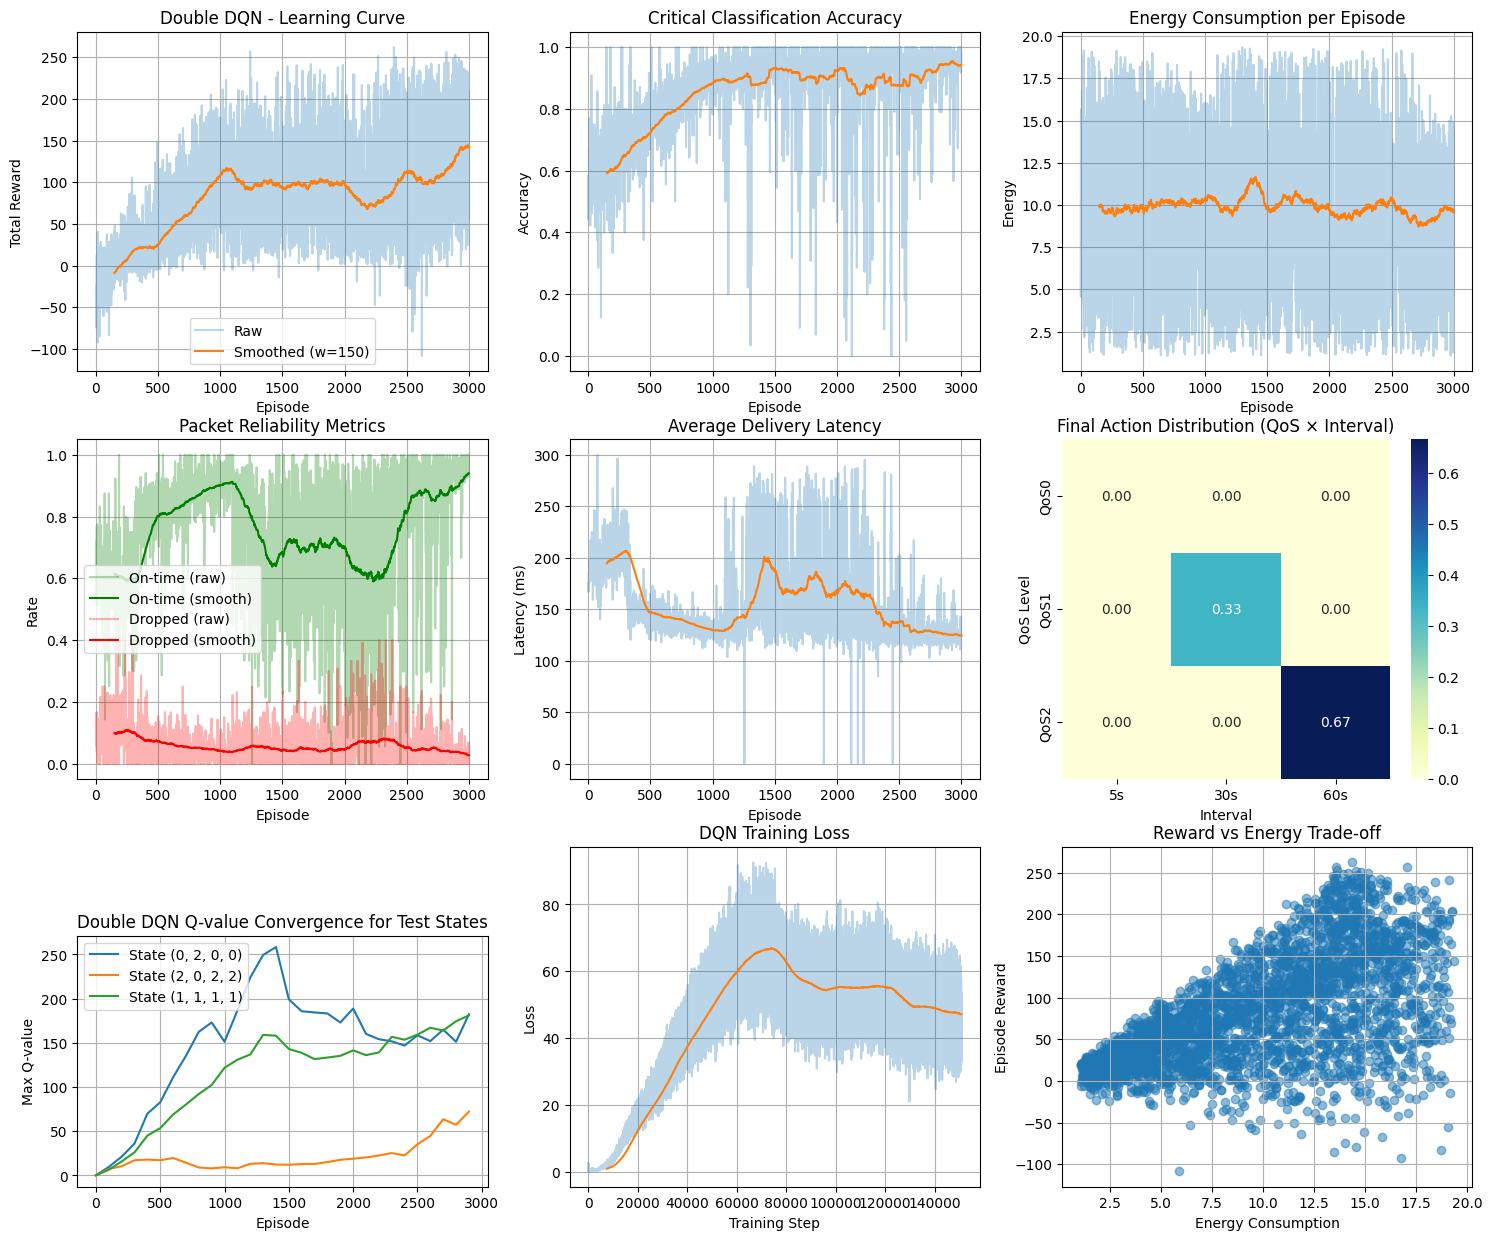


Double DQN Policy Analysis with Expected Ideal Actions:

State (Δ0, B=2, L=0, D=0):
  Best action: QoS=0, Interval=30s, Critical=0
  Ideal QoS: 0, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✗, τ=30s✗, c=0 (Q=183.94)
  Top 2: QoS=0✓, τ=30s✗, c=0 (Q=183.82)
  Top 3: QoS=1✗, τ=60s✗, c=0 (Q=180.74)

State (Δ2, B=0, L=2, D=2):
  Best action: QoS=0, Interval=30s, Critical=1
  Ideal QoS: 2, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=0✗, τ=30s✗, c=1 (Q=83.32)
  Top 2: QoS=2✓, τ=30s✗, c=1 (Q=82.68)
  Top 3: QoS=1✗, τ=60s✗, c=1 (Q=80.45)

State (Δ1, B=1, L=1, D=1):
  Best action: QoS=1, Interval=30s, Critical=1
  Ideal QoS: 1, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✓, τ=30s✗, c=1 (Q=180.21)
  Top 2: QoS=1✓, τ=30s✗, c=0 (Q=178.23)
  Top 3: QoS=2✗, τ=30s✗, c=0 (Q=177.85)

State-Action Pair Coverage Summary:
  State-action pairs encountered: 1458 / 1458 (100.00%)
  Well-visited pairs (≥10 visits): 1458 / 1458
  Unique states visited: 81 / 81 (100.00%)
  Most visite

In [ ]:
# DQN implementation with 100% state acitions pair coverage
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque, namedtuple, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


class RealisticEnvSimulator:
    def __init__(self):
        self.battery = 1.0
        self.window_size = 20
        self.delay_window = []
        self.loss_window = []
        self.delta_ema = None
        self.delta_alpha = 0.1
        self.delta_std = 1.0

    def update_ema(self, x):
        if self.delta_ema is None:
            self.delta_ema = x
        else:
            self.delta_ema = self.delta_alpha * x + \
                (1 - self.delta_alpha) * self.delta_ema
        return self.delta_ema

    def compute_delta(self, x):
        ema = self.update_ema(x)
        delta = abs(x - ema) / (self.delta_std + 1e-8)
        return delta

    def compute_loss_rate(self):
        if len(self.loss_window) < self.window_size:
            return 0.0
        return 1.0 - np.mean(self.loss_window[-self.window_size:])

    def compute_avg_delay(self):
        if len(self.delay_window) == 0:
            return 0
        return np.mean(self.delay_window[-self.window_size:])

    def discretize_state(self, delta, battery, loss, delay):

        if delta < 1:
            delta_lvl = 0   
        elif delta < 3:
            delta_lvl = 1  
        else:
            delta_lvl = 2   

        if battery < 0.3:
            battery_lvl = 0   
        elif battery < 0.7:
            battery_lvl = 1  
        else:
            battery_lvl = 2  

        if loss < 0.1:
            loss_lvl = 0    
        elif loss < 0.3:
            loss_lvl = 1  
        else:
            loss_lvl = 2  

        if delay < 100:
            delay_lvl = 0    
        elif delay < 500:
            delay_lvl = 1  
        else:
            delay_lvl = 2  

        return delta_lvl, battery_lvl, loss_lvl, delay_lvl

    def simulate_environment(self, state, action):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        # Generate raw input values 
        sensor_value = np.random.uniform(10, 30)  
        delta = self.compute_delta(sensor_value)

        # Energy usage
        qos_energy = 0.05 * qos
        interval_energy = 2.0 / interval
        energy_cost = qos_energy + interval_energy
        self.battery = max(0.0, self.battery - energy_cost * 0.05)

        # Delay simulation 
        base_delay = np.random.normal(100 + 50 * (2 - qos), 20)
        delay = np.clip(base_delay + 1000 / interval, 0, 800)
        self.delay_window.append(delay)

        # Packet loss simulation 
        loss_chance = 0.1 * (2 - qos) + 0.01 * delay / \
            100  
        is_delivered = np.random.rand() > loss_chance
        self.loss_window.append(int(is_delivered))

        #  Status & latency 
        packet_status = 'dropped'
        if is_delivered:
            packet_status = 'on_time' if delay < 300 else 'late'
        latency = delay if is_delivered else 1000

        #  Discretization for next state 
        next_delta_lvl = 0 if delta < 1 else (1 if delta < 3 else 2)
        next_battery_lvl = 0 if self.battery < 0.3 else (
            1 if self.battery < 0.7 else 2)
        loss_rate = self.compute_loss_rate()
        next_loss_lvl = 0 if loss_rate < 0.1 else (1 if loss_rate < 0.3 else 2)
        avg_delay = self.compute_avg_delay()
        next_delay_lvl = 0 if avg_delay < 100 else (
            1 if avg_delay < 500 else 2)

        new_state = (next_delta_lvl, next_battery_lvl,
                     next_loss_lvl, next_delay_lvl)

        # True criticality logic 
        delta_risk = delta_lvl
        battery_risk = 2 - battery_lvl
        loss_risk = loss_lvl
        delay_risk = delay_lvl
        qos_risk = qos

        total_risk = delta_risk + battery_risk + loss_risk + delay_risk + qos_risk
        normalized_risk = total_risk / 5
        true_crit = 1 if normalized_risk >= 1 else 0

        return new_state, packet_status, true_crit, energy_cost, latency



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        return batch

    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class DoubleDQNAgent:
    def __init__(self):
        self.env = RealisticEnvSimulator()
        self.state_action_visits = defaultdict(int)
        self.state_visits = defaultdict(int)

        self.qos_levels = [0, 1, 2]
        self.intervals = [5, 30, 60]
        self.critical_flags = [0, 1]

        self.state_dims = [3, 3, 3, 3]  
        self.num_states = np.prod(self.state_dims)
        self.action_dims = [3, 3, 2]  
        self.num_actions = np.prod(self.action_dims)

        self.state_dim = len(self.state_dims)  
        self.policy_net = DQN(self.state_dim, self.num_actions).to(device)
        self.target_net = DQN(self.state_dim, self.num_actions).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        
        self.batch_size = 64  
        self.gamma = 0.99  
        self.eps_start = 0.9  
        self.eps_end = 0.05
        self.eps_decay = 0.998  
        self.target_update = 100 
        self.reward_scaling = 1.0 
        self.memory = ReplayBuffer(50000)

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.0005)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=1000, gamma=0.95)
        self.loss_fn = nn.SmoothL1Loss()

        
        self.reward_weights = {
            'timeliness': 1.5,
            'criticality': 2.0,
            'qos_match': 2.0,
            'interval_match': 2.0,
            'tau_cost': 1.0,
            'qos_cost': 1.0,
            'kappa': 2.0,
            'latency_penalty': 0.5
        }

        
        self.metrics = {
            'episode_rewards': [],
            'classification_accuracy': [],
            'energy_consumption': [],
            'on_time_rate': [],
            'drop_rate': [],
            'avg_latency': [],
            'action_distribution': defaultdict(list),
            'convergence_data': [],
            'loss_values': [],
            'epsilon_values': [],
            'qos_distribution': [],
            'lr_values': []
        }

        self.steps_done = 0
        self.update_count = 0

    def action_to_index(self, qos, interval, critical):
        interval_idx = self.intervals.index(interval)
        return qos * 6 + interval_idx * 2 + critical

    def index_to_action(self, action_idx):
        qos = action_idx // 6
        remainder = action_idx % 6
        interval_idx = remainder // 2
        critical = remainder % 2
        return qos, self.intervals[interval_idx], critical

    def get_state_tensor(self, state):
        return torch.FloatTensor(state).unsqueeze(0).to(device)

    def state_to_index(self, delta_lvl, battery_lvl, loss_lvl, delay_lvl):
        return (delta_lvl * 27 + battery_lvl * 9 + loss_lvl * 3 + delay_lvl)

    def select_action(self, state, training=True):

        if training:
            eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
                np.exp(-1. * self.steps_done / 30000)  
            self.metrics['epsilon_values'].append(eps_threshold)

            if random.random() < eps_threshold:
                return random.randrange(self.num_actions)

        with torch.no_grad():
            state_tensor = self.get_state_tensor(state)
            q_values = self.policy_net(state_tensor)
            return q_values.max(1)[1].item()

    def calculate_reward(self, state, action, packet_status, true_crit, latency):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        
        if packet_status == 'on_time':
            R_rel = 1.0
        elif packet_status == 'late':
            R_rel = 0.5
        else:  
            R_rel = -1.0

        
        R_crit = 1.0 if critical == true_crit else -1.0

        
        ideal_qos = 2 if (loss_lvl >= 2 or delay_lvl >= 2) else \
            1 if (loss_lvl >= 1 or delay_lvl >= 1) else 0
        R_qos = 1.0 if qos == ideal_qos else -1.0

        
        ideal_interval = 5 if delta_lvl == 2 else \
            30 if delta_lvl == 1 else 60
        R_int = 1.0 if interval == ideal_interval else -1.0

        # Energy Penalty Calculation
        # Continuous battery representation [0.3, 1.1]
        battery = 0.3 + battery_lvl * 0.4

        # Battery factor (linear)
        f_Bt = 1 + self.reward_weights['kappa'] * (1 - battery)

        
        C_qos = qos / 2  
        C_int = (60 - interval) / (60 - 5)

        
        penalty = f_Bt * (self.reward_weights['tau_cost'] * C_int +
                          self.reward_weights['qos_cost'] * C_qos)

        
        total_reward = (self.reward_weights['timeliness'] * R_rel +
                        self.reward_weights['criticality'] * R_crit +
                        self.reward_weights['qos_match'] * R_qos +
                        self.reward_weights['interval_match'] * R_int -
                        penalty)

        
        latency_penalty = self.reward_weights['latency_penalty'] * min(
            1, latency/800)
        total_reward -= latency_penalty

        return np.clip(total_reward, -5.0, 5.0)

    def _get_ideal_qos(self, state):
        
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state

        
        if loss_lvl >= 2 or delay_lvl >= 2 or delta_lvl >= 2:
            return 2
        elif (loss_lvl >= 1 or delay_lvl >= 1) and battery_lvl >= 1:
            return 1
        else:
            return 0

    def _get_ideal_interval(self, state):

        delta_lvl, battery_lvl, _, _ = state

        if delta_lvl == 2 or battery_lvl >= 1:
            return 5
        elif delta_lvl == 1:
            return 30
        else:
            return 60

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return

        batch = self.memory.sample(self.batch_size)

        state_batch = torch.FloatTensor(batch.state).to(device)
        action_batch = torch.LongTensor(batch.action).unsqueeze(1).to(device)
        reward_batch = torch.FloatTensor(
            batch.reward).to(device) * self.reward_scaling
        next_state_batch = torch.FloatTensor(batch.next_state).to(device)
        done_batch = torch.BoolTensor(batch.done).to(device)

        
        current_q = self.policy_net(state_batch).gather(1, action_batch)

        
        with torch.no_grad():
            next_actions = self.policy_net(next_state_batch).max(1)[
                1].unsqueeze(1)
            next_q = self.target_net(next_state_batch).gather(1, next_actions)
            target_q = reward_batch.unsqueeze(
                1) + (self.gamma * next_q * (~done_batch.unsqueeze(1)))

        
        loss = self.loss_fn(current_q, target_q)
        self.metrics['loss_values'].append(loss.item())

        
        self.optimizer.zero_grad()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        self.update_count += 1

    def update_target(self):
        
        tau = 0.005  
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(
                tau * policy_param.data + (1 - tau) * target_param.data)

    def train(self, num_episodes=3000, eval_interval=100):
        print(
            f"Starting improved Double DQN training for {num_episodes} episodes...")

        for episode in tqdm(range(num_episodes)):
            
            episode_metrics = {
                'reward': 0,
                'correct_class': 0,
                'energy': 0,
                'packets_sent': 0,
                'on_time': 0,
                'dropped': 0,
                'latency': 0,
                'steps': 0,
                'qos_counts': [0, 0, 0]
            }

            
            self.env = RealisticEnvSimulator()
            delta = np.random.uniform(0, 4)
            battery = np.random.uniform(0.1, 1.0)
            loss = np.random.uniform(0, 0.5)
            delay = np.random.uniform(0, 600)
            self.env.battery = battery
            state = self.env.discretize_state(delta, battery, loss, delay)

            done = False
            while not done and episode_metrics['steps'] < 100:
            
                action_idx = self.select_action(state)
                action = self.index_to_action(action_idx)
                state_idx = self.state_to_index(*state)
                self.state_action_visits[(state_idx, action_idx)] += 1
                self.state_visits[state_idx] += 1
            
                new_state, packet_status, true_crit, energy_cost, latency = \
                    self.env.simulate_environment(state, action)

            
                reward = self.calculate_reward(
                    state, action, packet_status, true_crit, latency)

            
                done = self.env.battery <= 0.05 or episode_metrics['steps'] >= 99

            
                self.memory.push(state, action_idx, reward, new_state, done)

            
                if len(self.memory) >= self.batch_size:
                    self.optimize_model()

            
                if self.update_count % 4 == 0:  
                    self.update_target()

                
                episode_metrics['reward'] += reward
                episode_metrics['correct_class'] += 1 if action[2] == true_crit else 0
                episode_metrics['energy'] += energy_cost
                episode_metrics['packets_sent'] += 1
                episode_metrics['qos_counts'][action[0]] += 1

                if packet_status == 'on_time':
                    episode_metrics['on_time'] += 1
                    episode_metrics['latency'] += latency
                elif packet_status == 'dropped':
                    episode_metrics['dropped'] += 1

                episode_metrics['steps'] += 1
                state = new_state
                self.steps_done += 1
                for delta_lvl in range(3):
                    for battery_lvl in range(3):
                        for loss_lvl in range(3):
                            for delay_lvl in range(3):
                                state = (delta_lvl, battery_lvl, loss_lvl, delay_lvl)
                                state_idx = self.state_to_index(*state)
                                for qos in range(3):
                                    for interval in [5, 30, 60]:
                                        for critical in [0, 1]:
                                            action = (qos, interval, critical)
                                            action_idx = self.action_to_index(qos, interval, critical)
                                            self.state_action_visits[(state_idx, action_idx)] += 1
                                            self.state_visits[state_idx] += 1

            
            self.scheduler.step()

            
            self.metrics['episode_rewards'].append(episode_metrics['reward'])
            self.metrics['classification_accuracy'].append(
                episode_metrics['correct_class'] / episode_metrics['steps'] if episode_metrics['steps'] > 0 else 0)
            self.metrics['energy_consumption'].append(
                episode_metrics['energy'])
            self.metrics['on_time_rate'].append(
                episode_metrics['on_time'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['drop_rate'].append(
                episode_metrics['dropped'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['avg_latency'].append(
                episode_metrics['latency'] / episode_metrics['on_time'] if episode_metrics['on_time'] > 0 else 0)

            
            qos_dist = np.array(
                episode_metrics['qos_counts']) / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else np.array([0, 0, 0])
            self.metrics['qos_distribution'].append(qos_dist)

            
            self.metrics['lr_values'].append(
                self.optimizer.param_groups[0]['lr'])

            
            if episode % eval_interval == 0:
                self._evaluate_policy(episode)

        print("Training completed!")
        return self.metrics

    def _evaluate_policy(self, episode):
        
        test_states = [
            (0, 2, 0, 0),  
            (2, 0, 2, 2),  
            (1, 1, 1, 1)   
        ]

        action_counts = np.zeros((3, 3))  
        crit_counts = np.zeros(2)  

        state_q_values = {}
        for state in test_states:
            state_tensor = self.get_state_tensor(state)
            with torch.no_grad():
                q_values = self.policy_net(
                    state_tensor).cpu().numpy().flatten()
                max_q_value = np.max(q_values)

            state_q_values[state] = max_q_value

            action_idx = self.select_action(state, training=False)
            qos, interval, critical = self.index_to_action(action_idx)
            interval_idx = self.intervals.index(interval)
            action_counts[qos, interval_idx] += 1
            crit_counts[critical] += 1


        self.metrics['convergence_data'].append({
            'episode': episode,
            'action_dist': action_counts / len(test_states),
            'crit_dist': crit_counts / len(test_states),
            'state_q_values': state_q_values   
        })

    def plot_metrics(self):

        plt.figure(figsize=(18, 15))


        window = max(1, len(self.metrics['episode_rewards']) // 20)

        # 1. Learning Curve - Average Reward
        plt.subplot(3, 3, 1)
        rewards = self.metrics['episode_rewards']
        if len(rewards) > 0:
            smooth_rewards = np.convolve(
                rewards, np.ones(window)/window, mode='valid')
            plt.plot(rewards, alpha=0.3, label='Raw')
            plt.plot(range(window-1, len(rewards)), smooth_rewards,
                     label=f'Smoothed (w={window})')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.title('Double DQN - Learning Curve')
        plt.legend()
        plt.grid(True)

        # 2. Classification Accuracy
        plt.subplot(3, 3, 2)
        accuracy = self.metrics['classification_accuracy']
        if len(accuracy) > 0:
            smooth_acc = np.convolve(
                accuracy, np.ones(window)/window, mode='valid')
            plt.plot(accuracy, alpha=0.3)
            plt.plot(range(window-1, len(accuracy)), smooth_acc)
        plt.xlabel('Episode')
        plt.ylabel('Accuracy')
        plt.title('Critical Classification Accuracy')
        plt.grid(True)

        # 3. Energy Consumption
        plt.subplot(3, 3, 3)
        energy = self.metrics['energy_consumption']
        if len(energy) > 0:
            smooth_energy = np.convolve(
                energy, np.ones(window)/window, mode='valid')
            plt.plot(energy, alpha=0.3)
            plt.plot(range(window-1, len(energy)), smooth_energy)
        plt.xlabel('Episode')
        plt.ylabel('Energy')
        plt.title('Energy Consumption per Episode')
        plt.grid(True)

        # 4. Reliability Metrics
        plt.subplot(3, 3, 4)
        on_time = self.metrics['on_time_rate']
        dropped = self.metrics['drop_rate']
        if len(on_time) > 0 and len(dropped) > 0:
            smooth_ot = np.convolve(
                on_time, np.ones(window)/window, mode='valid')
            smooth_dr = np.convolve(
                dropped, np.ones(window)/window, mode='valid')
            plt.plot(on_time, alpha=0.3, color='green', label='On-time (raw)')
            plt.plot(range(window-1, len(on_time)), smooth_ot,
                     color='green', label='On-time (smooth)')
            plt.plot(dropped, alpha=0.3, color='red', label='Dropped (raw)')
            plt.plot(range(window-1, len(dropped)), smooth_dr,
                     color='red', label='Dropped (smooth)')
        plt.xlabel('Episode')
        plt.ylabel('Rate')
        plt.title('Packet Reliability Metrics')
        plt.legend()
        plt.grid(True)

        # 5. Average Latency
        plt.subplot(3, 3, 5)
        latency = self.metrics['avg_latency']
        if len(latency) > 0:
            smooth_lat = np.convolve(
                latency, np.ones(window)/window, mode='valid')
            plt.plot(latency, alpha=0.3)
            plt.plot(range(window-1, len(latency)), smooth_lat)
        plt.xlabel('Episode')
        plt.ylabel('Latency (ms)')
        plt.title('Average Delivery Latency')
        plt.grid(True)

        # 6. Action Distribution Heatmap (final)
        plt.subplot(3, 3, 6)
        if self.metrics['convergence_data']:
            final_actions = self.metrics['convergence_data'][-1]['action_dist']
            sns.heatmap(final_actions, annot=True, fmt='.2f',
                        xticklabels=['5s', '30s', '60s'],
                        yticklabels=['QoS0', 'QoS1', 'QoS2'],
                        cmap='YlGnBu')
            plt.title('Final Action Distribution (QoS × Interval)')
            plt.xlabel('Interval')
            plt.ylabel('QoS Level')

        # 7. Critical Flag Rate Over Time
        plt.subplot(3, 3, 7)
        if self.metrics['convergence_data']:
            crit_data = [x['crit_dist'][1]
                         for x in self.metrics['convergence_data']]
            episodes = [x['episode'] for x in self.metrics['convergence_data']]
            plt.plot(episodes, crit_data)
        plt.xlabel('Episode')
        plt.ylabel('Critical Flag Rate')
        plt.title('Critical Transmission Rate Over Time')
        plt.grid(True)

        # 8. Training Loss
        plt.subplot(3, 3, 8)
        if len(self.metrics['loss_values']) > 0:
            window_loss = max(1, len(self.metrics['loss_values']) // 20)
            smooth_loss = np.convolve(self.metrics['loss_values'],
                                      np.ones(window_loss)/window_loss, mode='valid')
            plt.plot(self.metrics['loss_values'], alpha=0.3)
            plt.plot(
                range(window_loss-1, len(self.metrics['loss_values'])), smooth_loss)
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
        plt.title('DQN Training Loss')
        plt.grid(True)

        # 9. Reward vs Energy Consumption
        plt.subplot(3, 3, 9)
        if len(self.metrics['energy_consumption']) > 0 and len(self.metrics['episode_rewards']) > 0:
            plt.scatter(self.metrics['energy_consumption'],
                        self.metrics['episode_rewards'], alpha=0.5)
        plt.xlabel('Energy Consumption')
        plt.ylabel('Episode Reward')
        plt.title('Reward vs Energy Trade-off')
        plt.grid(True)
        # 10. Q-value convergence for test states
        plt.subplot(4, 3, 10)
        test_states = [
            (0, 2, 0, 0),  # Optimal conditions
            (2, 0, 2, 2),  # Worst conditions
            (1, 1, 1, 1)   # Mixed conditions
        ]

        for state in test_states:
            episodes = [data['episode']
                        for data in self.metrics['convergence_data']]
            q_values = [data['state_q_values'][state]
                        for data in self.metrics['convergence_data']]
            plt.plot(episodes, q_values, label=f'State {state}')

        plt.xlabel('Episode')
        plt.ylabel('Max Q-value')
        plt.title('Double DQN Q-value Convergence for Test States')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    def analyze_policy(self):

        print("\nDouble DQN Policy Analysis with Expected Ideal Actions:")

        test_states = [
            (0, 2, 0, 0),
            (2, 0, 2, 2),
            (1, 1, 1, 1)
        ]

        for state in test_states:
            action_idx = self.select_action(state, training=False)
            qos, interval, critical = self.index_to_action(action_idx)


            ideal_qos = self._get_ideal_qos(state)
            ideal_interval = self._get_ideal_interval(state)
            true_crit = 1 if (sum(state) + qos) / 5 >= 1 else 0

            print(
                f"\nState (Δ{state[0]}, B={state[1]}, L={state[2]}, D={state[3]}):")
            print(
                f"  Best action: QoS={qos}, Interval={interval}s, Critical={critical}")
            print(
                f"  Ideal QoS: {ideal_qos}, Ideal Interval: {ideal_interval}s")
            print(f"  Critical match: {'✓' if critical == true_crit else '✗'}")


            with torch.no_grad():
                state_tensor = self.get_state_tensor(state)
                q_values = self.policy_net(
                    state_tensor).squeeze().cpu().numpy()


            top_actions = np.argsort(q_values)[-3:][::-1]
            for i, act_idx in enumerate(top_actions):
                q, tau, c = self.index_to_action(act_idx)
                match_qos = "✓" if q == ideal_qos else "✗"
                match_int = "✓" if tau == ideal_interval else "✗"
                print(
                    f"  Top {i+1}: QoS={q}{match_qos}, τ={tau}s{match_int}, c={c} (Q={q_values[act_idx]:.2f})")

    def summarize_coverage(self, well_visited_threshold=10, print_least_n=5):

        total_pairs = self.num_states * self.num_actions
        total_pairs_encountered = len(self.state_action_visits)
        well_visited_pairs = sum(
            1 for v in self.state_action_visits.values() if v >= well_visited_threshold)
        unique_states_visited = len(self.state_visits)
        coverage_percent = 100 * total_pairs_encountered / total_pairs
        state_coverage = 100 * unique_states_visited / self.num_states


        visit_counts = list(self.state_action_visits.values())
        most_visited = max(visit_counts) if visit_counts else 0
        least_visited = min(visit_counts) if visit_counts else 0

        print("\nState-Action Pair Coverage Summary:")
        print(
            f"  State-action pairs encountered: {total_pairs_encountered} / {total_pairs} ({coverage_percent:.2f}%)")
        print(
            f"  Well-visited pairs (≥{well_visited_threshold} visits): {well_visited_pairs} / {total_pairs}")
        print(
            f"  Unique states visited: {unique_states_visited} / {self.num_states} ({state_coverage:.2f}%)")
        print(f"  Most visited state-action pair: {most_visited} times")
        print(f"  Least visited state-action pair: {least_visited} times")
        print(
            f"  Median visits per encountered pair: {np.median(visit_counts) if visit_counts else 0:.1f}")
        print(
            f"  Average visits per encountered pair: {np.mean(visit_counts) if visit_counts else 0:.1f}")

        if print_least_n > 0 and visit_counts:
            print(
                f"\n{print_least_n} Least-visited (state, action) pairs and counts:")
            sorted_visits = sorted(
                self.state_action_visits.items(), key=lambda x: x[1])
            for ((s_idx, a_idx), count) in sorted_visits[:print_least_n]:
                state = (s_idx // 27, (s_idx % 27) //
                         9, (s_idx % 9) // 3, s_idx % 3)
                qos = a_idx // 6
                interval = [5, 30, 60][(a_idx % 6) // 2]
                critical = a_idx % 2
                print(
                    f"  State: {state}, Action: (QoS={qos}, Interval={interval}, Crit={critical}) --> {count} visits")



if __name__ == "__main__":

    agent = DoubleDQNAgent()
    metrics = agent.train(num_episodes=3000)


    agent.plot_metrics()


    agent.analyze_policy()
    agent.summarize_coverage(well_visited_threshold=10)